In [1]:
import pandas as pd

df = pd.read_csv("dataset/train delay data.csv")
print(df.head())
print(df.info())
print(df.describe())


   Distance Between Stations (km) Weather Conditions Day of the Week  \
0                             100              Clear          Monday   
1                             150              Rainy         Tuesday   
2                             200              Foggy       Wednesday   
3                              50              Clear        Thursday   
4                              75              Rainy          Friday   

  Time of Day Train Type  Historical Delay (min) Route Congestion  
0     Morning    Express                       5              Low  
1   Afternoon  Superfast                      10           Medium  
2     Evening      Local                      15             High  
3       Night    Express                       2              Low  
4     Morning  Superfast                       8           Medium  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2878 entries, 0 to 2877
Data columns (total 7 columns):
 #   Column                          Non-Null Count  

In [6]:
df.head()

,Distance Between Stations (km),Weather Conditions,Day of the Week,Time of Day,Train Type,Historical Delay (min),Route Congestion
0,100,Clear,Monday,Morning,Express,5,Low
1,150,Rainy,Tuesday,Afternoon,Superfast,10,Medium
2,200,Foggy,Wednesday,Evening,Local,15,High
3,50,Clear,Thursday,Night,Express,2,Low
4,75,Rainy,Friday,Morning,Superfast,8,Medium


In [7]:
df.tail()

,Distance Between Stations (km),Weather Conditions,Day of the Week,Time of Day,Train Type,Historical Delay (min),Route Congestion
2873,945,Clear,Tuesday,Night,Local,1210,Medium
2874,925,Rainy,Wednesday,Morning,Express,1215,High
2875,950,Foggy,Thursday,Afternoon,Superfast,1220,Low
2876,930,Clear,Friday,Evening,Local,1225,Medium
2877,955,Rainy,Saturday,Night,Express,1230,High


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("dataset/train delay data.csv")

X = df.drop("Historical Delay (min)", axis=1)
y = df["Historical Delay (min)"]

categorical_features = ['Weather Conditions', 'Day of the Week', 'Time of Day', 'Train Type', 'Route Congestion']
numerical_features = ['Distance Between Stations (km)']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough'  # keep numerical features
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)


y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")


MAE: 31.327349194883052
RMSE: 54.73957176904805
R2 Score: 0.9310040299523088


In [17]:
# Predict on test set
y_pred = pipeline.predict(X_test)

# Print comparison of actual vs predicted
comparison_df = pd.DataFrame({
    'Actual Delay (min)': y_test,
    'Predicted Delay (min)': y_pred
})

print(comparison_df.head(10))


      Actual Delay (min)  Predicted Delay (min)
471                    7              73.051083
1453                  53              44.426333
2376                   0               1.274167
1601                  70              19.531129
1094                  10              53.438738
1255                  67              61.021833
1128                  48              61.021833
2251                 157              41.520333
945                    0              40.361000
1800                   0               2.370000


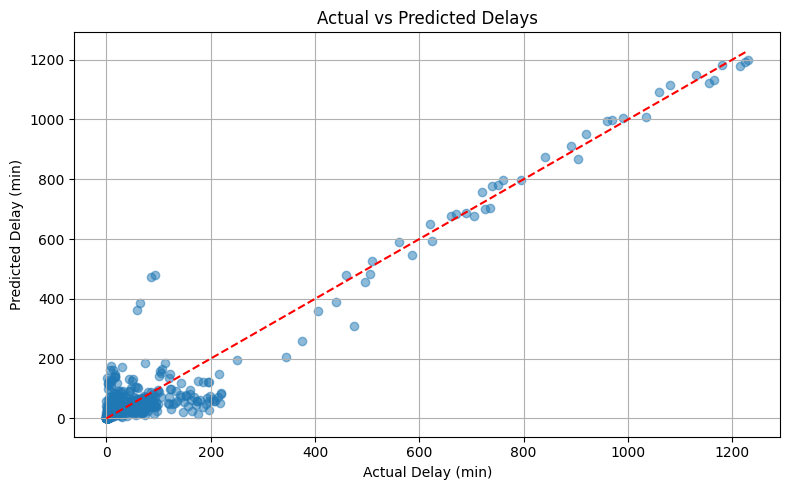

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')
plt.xlabel("Actual Delay (min)")
plt.ylabel("Predicted Delay (min)")
plt.title("Actual vs Predicted Delays")
plt.grid(True)
plt.tight_layout()
plt.show()


In [19]:
importances = pipeline.named_steps['model'].feature_importances_
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance:.4f}")


cat__Weather Conditions_Foggy: 0.0020
cat__Weather Conditions_Rainy: 0.0012
cat__Day of the Week_Monday: 0.0021
cat__Day of the Week_Saturday: 0.0020
cat__Day of the Week_Sunday: 0.0020
cat__Day of the Week_Thursday: 0.0024
cat__Day of the Week_Tuesday: 0.0019
cat__Day of the Week_Wednesday: 0.0017
cat__Time of Day_Evening: 0.0027
cat__Time of Day_Morning: 0.0029
cat__Time of Day_Night: 0.0026
cat__Train Type_Local: 0.0052
cat__Train Type_Superfast: 0.0019
cat__Route Congestion_Low: 0.0011
cat__Route Congestion_Medium: 0.0030
remainder__Distance Between Stations (km): 0.9655


# a nn model so that model learns from more features 

In [20]:
df.head()

,Distance Between Stations (km),Weather Conditions,Day of the Week,Time of Day,Train Type,Historical Delay (min),Route Congestion
0,100,Clear,Monday,Morning,Express,5,Low
1,150,Rainy,Tuesday,Afternoon,Superfast,10,Medium
2,200,Foggy,Wednesday,Evening,Local,15,High
3,50,Clear,Thursday,Night,Express,2,Low
4,75,Rainy,Friday,Morning,Superfast,8,Medium


In [25]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('dataset/train delay data.csv')

# Target column
target = 'Historical Delay (min)'

# Numerical and categorical columns
num_cols = ['Distance Between Stations (km)']
cat_cols = ['Weather Conditions', 'Day of the Week', 'Time of Day', 'Train Type', 'Route Congestion']

# Label encoding for categorical columns
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Standard scaling for numerical columns
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Split dataset into features (X) and target (y)
X = df[num_cols + cat_cols].values
y = df[target].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)  # Reshaping y to match the output dimension
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)  # Reshaping y to match the output dimension

# Define the model
class TrainTrain(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.model(x)

# Instantiate the model
model = TrainTrain(X_train.shape[1])

# Loss function and optimizer
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
for epoch in range(300):
    model.train()
    optimizer.zero_grad()
    pred = model(X_train)
    loss = loss_fn(pred, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Evaluation
model.eval()
with torch.no_grad():
    preds = model(X_test)
    mae = torch.mean(torch.abs(preds - y_test)).item()
    rmse = torch.sqrt(torch.mean((preds - y_test) ** 2)).item()

print(f"\nMAE: {mae:.2f}, RMSE: {rmse:.2f}")


Epoch 0, Loss: 45544.3125
Epoch 50, Loss: 41837.5078
Epoch 100, Loss: 33803.2930
Epoch 150, Loss: 27710.1562
Epoch 200, Loss: 18970.8984
Epoch 250, Loss: 10433.6973

MAE: 52.82, RMSE: 80.52


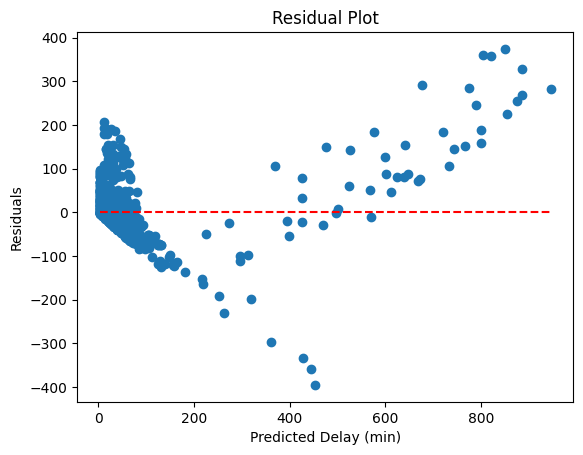

In [26]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_test - preds

# Plot residuals
plt.scatter(preds, residuals)
plt.hlines(0, xmin=min(preds), xmax=max(preds), colors='r', linestyles='dashed')
plt.xlabel('Predicted Delay (min)')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()
